# LLM-as-a-Judge: Tutor Feedback Evaluation


In [1]:
import requests
import json
import os
from tqdm import tqdm

## LLM-as-a-Judge Example

### Conversation History

The context in which these responses were given:


In [11]:
conversation_history = """Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is: Tyson decided to make muffaletta sandwiches for the big game.  Each sandwich required 1 pound each of meat and cheese and would serve 4 people.  There would be 20 people in total watching the game.  The meat cost $7.00 per pound and the cheese cost $3.00 per pound.  How much money would he spend on the meat and cheese to make enough sandwiches to serve 20 people? 
Student: To serve 20 people, Tyson needs to make 20/4 = 5 sandwiches.
Each sandwich requires 1+1 = 2 pounds of meat and cheese.
For 5 sandwiches, he needs a total of 2 x 5 = 10 pounds of meat and cheese.
The cost of 10 pounds of meat is 10 x $7.00 = $70.
The cost of 10 pounds of cheese is 10 x $3.00 = $30.
The total cost of meat and cheese is $70 + $30 = $100.
 100 
Tutor: How many pounds of meat are needed for each sandwich? 
Student: Each sandwich requires 1 pound of meat and 1 pound of cheese. 
Tutor: What is the cost of 1 pound of meat? 
Student: The cost of 1 pound of meat is $7.00."""

print("Conversation History:")
print(conversation_history)

Conversation History:
Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is: Tyson decided to make muffaletta sandwiches for the big game.  Each sandwich required 1 pound each of meat and cheese and would serve 4 people.  There would be 20 people in total watching the game.  The meat cost $7.00 per pound and the cheese cost $3.00 per pound.  How much money would he spend on the meat and cheese to make enough sandwiches to serve 20 people? 
Student: To serve 20 people, Tyson needs to make 20/4 = 5 sandwiches.
Each sandwich requires 1+1 = 2 pounds of meat and cheese.
For 5 sandwiches, he needs a total of 2 x 5 = 10 pounds of meat and cheese.
The cost of 10 pounds of meat is 10 x $7.00 = $70.
The cost of 10 pounds of cheese is 10 x $3.00 = $30.
The total cost of meat and cheese is $70 + $30 = $100.
 100 
Tutor: How many pounds of meat are needed for each sandwich? 
Student: Each sandwich requires 1 pound of meat and 1 pound of cheese. 
Tutor: 

## Sample Feedback Responses

These are the two tutor responses we'll compare:


In [36]:
# Original response
original_response = "Great, you've correctly identified the cost of the meat, now let's focus on calculating the total cost of meat for all the sandwiches needed."

# Refined response
refined_response = """You’re on the right track with the number of sandwiches, but there’s a mix‑up in the weight calculation.  \n**Where the mistake is:**  \n> “For 5 sandwiches, he needs a total of 2 × 5 = 10 pounds of meat and cheese.”  \n\nThat 10 pounds is the combined weight of meat **and** cheese, not 10 pounds of each.  \n\n**What to do next:**  \n1. Split the 10 pounds into the amount of meat and the amount of cheese (they’re each 1 lb per sandwich).  \n2. Multiply the pounds of each ingredient by its unit price.  \n3. Add the two costs together.  \n\nGive it a try—just keep the two ingredients separate in your calculation. You’ll see the total cost comes out lower than $100. Good luck!"""

print("Original Response:")
print(original_response)
print("\n" + "="*80 + "\n")
print("Refined Response:")
print(refined_response)

Original Response:
Great, you've correctly identified the cost of the meat, now let's focus on calculating the total cost of meat for all the sandwiches needed.


Refined Response:
You’re on the right track with the number of sandwiches, but there’s a mix‑up in the weight calculation.  
**Where the mistake is:**  
> “For 5 sandwiches, he needs a total of 2 × 5 = 10 pounds of meat and cheese.”  

That 10 pounds is the combined weight of meat **and** cheese, not 10 pounds of each.  

**What to do next:**  
1. Split the 10 pounds into the amount of meat and the amount of cheese (they’re each 1 lb per sandwich).  
2. Multiply the pounds of each ingredient by its unit price.  
3. Add the two costs together.  

Give it a try—just keep the two ingredients separate in your calculation. You’ll see the total cost comes out lower than $100. Good luck!


## Ollama API Function

Function to call Ollama's selene-mini model:


In [2]:
def call_ollama(prompt, model="atla/selene-mini"):
    """
    Call Ollama API with the given prompt
    """
    url = "http://localhost:11434/api/generate"
    
    payload = {
        "model": model,
        "prompt": prompt,
        "stream": False,
        "temperature": 0.2,
    }
    
    try:
        response = requests.post(url, json=payload)
        response.raise_for_status()
        return response.json()["response"]
    except Exception as e:
        return f"Error calling Ollama: {str(e)}"

## Scoring


In [3]:
def create_scoring_prompt(response, history, definition, rubric):
    """
    Create a prompt to score a single response
    """
    return f"""### System:
You are a critic evaluating a tutor's interaction with a student, responsible for providing a clear and objective single evaluation
score based on specific criteria. Each assessment must accurately reflect the absolute performance standards.


### User:
# Task Description: The assessment of the ###Tutor's Final Response should be based on the following: ###Previous Conversation between Tutor and Student, ###Definitions of criteria and

# Scoring Rubric.
(1). Write a one-sentence feedback that assesses the quality of only the tutor's final response and Rate only the # Tutor's Final Response strictly based on the given scoring rubric and criteria, not evaluating in general.
(2). After writing feedback, write a score that is an integer between 1 and 3. You should refer to the scoring rubric.
(3). The output format should look as follows:
"Feedback: (write a feedback for criteria)
Score: (an integer number between 1 and 3)"
(4). Please do not generate other opening, closing, or explanations.

# Previous Conversation between Tutor and Student: {history}

# Definitions of criteria: {definition}

# Scoring Rubric: {rubric}

# Tutor's Final Response: {response}


### Assistant:
# Generate Assessment Score:
"""

In [4]:
definition = {
    "mistake_identification": "Has the tutor identified a mistake in a student's response?",
    "mistake_location": "Does the tutor's response accurately point to a genuine mistake and its location?",
    "providing_guidance": "Does the tutor offer correct and relevant guidance, such as an explanation, elaboration, hint, examples, and so on, and does not reveal the answer?",
    "actionability": "Is it clear from the tutor's feedback what the student should do next?",
}

mistake_identification_rubric = """
[Has the tutor identified a mistake in a student's response?]
Score 1: No
Score 2: To some extent
Score 3: Yes
""".strip()

mistake_location_rubric = """
[Does the tutor's response accurately point to a genuine mistake and its location?]
Score 1: No
Score 2: To some extent
Score 3: Yes
""".strip()

providing_guidance_rubric = """
[Does the tutor offer correct and relevant guidance, such as an explanation, elaboration, hint, examples, and so on, and does not reveal the answer?]
Score 1: No
Score 2: To some extent (guidance is provided but it is fully or partially incorrect or incomplete)
Score 3: Yes (guidance is correct and relevant to the mistake)
""".strip()

actionability_rubric = """
[Is it clear from the tutor's feedback what the student should do next?]
Score 1: No
Score 2: To some extent
Score 3: Yes
""".strip()

In [90]:
# Score Original Response
print("="*80)
print("SCORING ORIGINAL RESPONSE")
print("="*80)

for criterion, rubric in zip(definition.keys(), [mistake_identification_rubric, mistake_location_rubric, providing_guidance_rubric, actionability_rubric]):
    prompt = create_scoring_prompt(original_response, conversation_history, definition[criterion], rubric)
    evaluation = call_ollama(prompt)
    print(f"--- {criterion} ---")
    print(evaluation)
    print("\n")

SCORING ORIGINAL RESPONSE
--- mistake_identification ---
Feedback: The tutor has acknowledged the student's correct identification of the meat cost but failed to address the student's previous calculation errors regarding the number of sandwiches and pounds required.
Score: 1


--- mistake_location ---
Feedback: The tutor's response does not accurately point to a genuine mistake, but rather encourages further calculation without addressing any errors in the student's reasoning.
Score: 1


--- providing_guidance ---
Feedback: The tutor provided a vague statement without addressing the student's misunderstanding about the amount of meat needed per sandwich.
Score: 1


--- actionability ---
Feedback: The tutor's final response clearly indicates that the student should continue to calculate the total cost of meat for all the required sandwiches, providing a clear direction for next steps.
Score: 3




In [92]:
# Score Refined Response
print("="*80)
print("SCORING REFINED RESPONSE")
print("="*80)
for criterion, rubric in zip(definition.keys(), [mistake_identification_rubric, mistake_location_rubric, providing_guidance_rubric, actionability_rubric]):
    refined_prompt = create_scoring_prompt(refined_response, conversation_history, definition[criterion], rubric)
    refined_evaluation = call_ollama(refined_prompt)
    print(f"--- {criterion} ---")
    print(refined_evaluation)
    print("\n")

SCORING REFINED RESPONSE
--- mistake_identification ---
Feedback: The tutor effectively identified a critical mistake in the student's weight calculation and clearly explained how to rectify it, providing step-by-step guidance that is accurate and actionable.
Score: 3


--- mistake_location ---
Feedback: The tutor's response accurately points to a specific mistake and guides the student on how to correct it, providing clear steps for improvement.
Score: 3


--- providing_guidance ---
Feedback: The tutor provides accurate and relevant guidance to help the student correct their weight calculation, ensuring clarity and encouraging critical thinking.
Score: 3


--- actionability ---
Feedback: The tutor clearly indicates what the student should do next, which is to split the weight of each ingredient and calculate their costs separately.
Score: 3




In [5]:
def parse_llm_response(response):
    """
    Parse LLM response in the format:
    Feedback: <feedback>
    Score: <int>
    
    Args:
        response (str): The LLM response string
        
    Returns:
        dict: A dictionary with 'feedback' and 'score' keys
    """
    result = {
        'feedback': None,
        'score': None
    }
    
    lines = response.strip().split('\n')
    
    for line in lines:
        if line.startswith('Feedback:'):
            result['feedback'] = line.replace('Feedback:', '').strip()
        elif line.startswith('Score:'):
            try:
                score_str = line.replace('Score:', '').strip()
                result['score'] = int(score_str)
            except ValueError:
                result['score'] = None
    
    return result

### Run Batch Processing

Execute the batch scoring:


In [6]:
def load_conversation_histories(json_file_path):
    """
    Load conversation histories from the JSON file
    Returns a dictionary mapping conversation_id to conversation_history
    """
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Create a mapping from conversation_id to conversation_history
    history_map = {}
    for item in data:
        history_map[item['conversation_id']] = item['conversation_history']
    
    return history_map

def score_conversation_responses(original_response, refined_response, conv_history, model="atla/selene-mini"):
    """
    Score both original and refined responses for a conversation
    Returns a dictionary with scores for both responses
    """
    
    # Score original response
    original_scores = {}
    for criterion, rubric in zip(definition.keys(), [mistake_identification_rubric, mistake_location_rubric, providing_guidance_rubric, actionability_rubric]):
        original_prompt = create_scoring_prompt(original_response, conv_history, definition[criterion], rubric)
        llm_response = call_ollama(original_prompt, model)
        parsed = parse_llm_response(llm_response)
        original_scores[criterion] = parsed
    
    # Score refined response
    refined_scores = {}
    for criterion, rubric in zip(definition.keys(), [mistake_identification_rubric, mistake_location_rubric, providing_guidance_rubric, actionability_rubric]):
        refined_prompt = create_scoring_prompt(refined_response, conv_history, definition[criterion], rubric)
        llm_response = call_ollama(refined_prompt, model)
        parsed = parse_llm_response(llm_response)
        refined_scores[criterion] = parsed
    
    # Calculate overall scores
    if original_scores:
        original_scores['overall_score'] = round(sum([
            original_scores.get('mistake_identification', {}).get('score', 1) or 1,
            original_scores.get('mistake_location', {}).get('score', 1) or 1,
            original_scores.get('providing_guidance', {}).get('score', 1) or 1,
            original_scores.get('actionability', {}).get('score', 1) or 1
        ]) / 4, 2)
    
    if refined_scores:
        refined_scores['overall_score'] = round(sum([
            refined_scores.get('mistake_identification', {}).get('score', 1) or 1,
            refined_scores.get('mistake_location', {}).get('score', 1) or 1,
            refined_scores.get('providing_guidance', {}).get('score', 1) or 1,
            refined_scores.get('actionability', {}).get('score', 1) or 1
        ]) / 4, 2)
    
    return {
        "original_scores": original_scores,
        "refined_scores": refined_scores,
    }

def process_all_conversations(refinements_jsonl_path, conversations_json_path, output_path, model="atla/selene-mini"):
    """
    Process all conversations from the JSONL file and score them.
    Resumes from where it left off if the output file already exists.
    Handles multiple feedback responses per conversation_id.
    """
    # Load existing results if available
    existing_results = []
    processed_pairs = set()
    
    if os.path.exists(output_path):
        try:
            with open(output_path, 'r', encoding='utf-8') as f:
                existing_results = json.load(f)
            # Create a set of (conversation_id, original_response, refined_response) tuples
            processed_pairs = {
                (
                    item['conversation_id'],
                    item['original_response'],
                    item['refined_response']
                ) for item in existing_results
            }
            print(f"Found {len(processed_pairs)} already processed response pairs. Resuming...")
        except Exception as e:
            print(f"Could not read existing results ({e}). Starting fresh...")
    
    # Load conversation histories
    history_map = load_conversation_histories(conversations_json_path)
    
    # Process JSONL file
    results = existing_results.copy()
    total_count = len(existing_results)
    success_count = sum(1 for r in existing_results if r['llm_judge_scores']['original_scores'] and r['llm_judge_scores']['refined_scores'])
    skipped_count = 0
    identical_skipped_count = 0
    
    # Count total lines for progress bar
    total_lines = sum(1 for _ in open(refinements_jsonl_path, 'r', encoding='utf-8'))
    
    with open(refinements_jsonl_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, total=total_lines, desc="Processing"):
            data = json.loads(line.strip())
            conversation_id = data['conversation_id']
            orig_response = data['original_response']
            refined_resp = data['refined_response']
            
            # Create unique identifier for this response pair
            pair_key = (conversation_id, orig_response, refined_resp)
            
            # Skip if already processed
            if pair_key in processed_pairs:
                skipped_count += 1
                continue
            
            # Get conversation history
            conv_history = history_map.get(conversation_id)
            # if not conv_history:
            #     print(f"  WARNING: No conversation history found for {conversation_id}, skipping...")
            #     continue
            
            # Score both responses
            if orig_response != refined_resp:
                scores = score_conversation_responses(
                    orig_response,
                    refined_resp,
                    conv_history,
                    model
                )
                
                # Combine with original data
                result = {
                    "conversation_id": conversation_id,
                    "model_alias": data.get('model_alias', 'Unknown'),
                    "original_response": orig_response,
                    "refined_response": refined_resp,
                    "llm_judge_scores": scores
                }
                
                results.append(result)
                total_count += 1
                
                if scores['original_scores'] and scores['refined_scores']:
                    success_count += 1
                
                # Save intermediate results every 10 new conversations
                if total_count % 10 == 0:
                    # print(f"  Saving progress ({total_count} total, {skipped_count} already done)...")
                    with open(output_path, 'w', encoding='utf-8') as out_f:
                        json.dump(results, out_f, indent=2)
            
            else:
                identical_skipped_count += 1
                # print(f"  Skipping identical responses for conversation {conversation_id}.")
    
    # Save final results
    print(f"\n{'='*80}")
    print(f"Processing complete!")
    print(f"Skipped (already processed): {skipped_count}")
    print(f"Skipped (identical responses): {identical_skipped_count}")
    print(f"Newly processed: {total_count - len(existing_results)}")
    print(f"Total response pairs: {total_count}")
    print(f"Successfully scored: {success_count}")
    print(f"Saving final results to {output_path}...")
    
    with open(output_path, 'w', encoding='utf-8') as out_f:
        json.dump(results, out_f, indent=2)
    
    print(f"Results saved successfully!")
    return results

In [7]:
# Define file paths
refinements_file = "outputs/mrbench_v3_devset_refinements.jsonl"
conversations_file = "BEA Dataset/mrbench_v3_devset.json"
output_file = "outputs/llm_judge_scores.json"

# Process all conversations
results = process_all_conversations(
    refinements_file,
    conversations_file,
    output_file,
)

Found 1600 already processed response pairs. Resuming...


Processing: 100%|██████████| 2476/2476 [35:10<00:00,  1.17it/s]   


Processing complete!
Skipped (already processed): 1600
Skipped (identical responses): 788
Newly processed: 88
Total response pairs: 1688
Successfully scored: 1688
Saving final results to outputs/llm_judge_scores.json...
Results saved successfully!


### Analyze Results

Summary statistics of the scoring:


In [3]:
refinements_file = "outputs/mrbench_v3_devset_refinements.jsonl"
conversations_file = "BEA Dataset/mrbench_v3_devset.json"
output_file = "outputs/llm_judge_scores.json"

In [4]:
results = json.load(open(output_file, 'r', encoding='utf-8'))

In [8]:
# Analyze the results
from statistics import pstdev

print("="*80)
print("SUMMARY STATISTICS")
print("="*80)

criteria = [
    "mistake_identification",
    "mistake_location",
    "providing_guidance",
    "actionability",
]

original_overall = []
refined_overall = []
original_by_criterion = {c: [] for c in criteria}
refined_by_criterion = {c: [] for c in criteria}

for result in results:
    original_scores = result['llm_judge_scores'].get('original_scores', {})
    refined_scores = result['llm_judge_scores'].get('refined_scores', {})

    if original_scores:
        overall = original_scores.get('overall_score')
        if overall is not None:
            original_overall.append(overall)
        for c in criteria:
            score = original_scores.get(c, {}).get('score')
            if score is not None:
                original_by_criterion[c].append(score)

    if refined_scores:
        overall = refined_scores.get('overall_score')
        if overall is not None:
            refined_overall.append(overall)
        for c in criteria:
            score = refined_scores.get(c, {}).get('score')
            if score is not None:
                refined_by_criterion[c].append(score)


def safe_std(values):
    return pstdev(values) if len(values) > 1 else 0.0


def format_stats(values):
    if not values:
        return "Count: 0 | Average: n/a | Std Dev: n/a"
    avg = sum(values) / len(values)
    std = safe_std(values)
    return f"Count: {len(values)} | Average: {avg:.2f} | Std Dev: {std:.2f}"


print("\nOverall:")
print(f"  Original -> {format_stats(original_overall)}")
print(f"  Refined  -> {format_stats(refined_overall)}")

for c in criteria:
    print(f"\n{c}:")
    print(f"  Original -> {format_stats(original_by_criterion[c])}")
    print(f"  Refined  -> {format_stats(refined_by_criterion[c])}")

if original_overall and refined_overall:
    avg_improvement = sum(refined_overall)/len(refined_overall) - sum(original_overall)/len(original_overall)
    print(f"\nAverage Improvement: {avg_improvement:+.2f}")

SUMMARY STATISTICS

Overall:
  Original -> Count: 1688 | Average: 2.09 | Std Dev: 0.66
  Refined  -> Count: 1688 | Average: 2.89 | Std Dev: 0.23

mistake_identification:
  Original -> Count: 1688 | Average: 2.08 | Std Dev: 0.87
  Refined  -> Count: 1688 | Average: 2.82 | Std Dev: 0.46

mistake_location:
  Original -> Count: 1688 | Average: 2.20 | Std Dev: 0.77
  Refined  -> Count: 1688 | Average: 2.89 | Std Dev: 0.32

providing_guidance:
  Original -> Count: 1688 | Average: 1.98 | Std Dev: 0.80
  Refined  -> Count: 1688 | Average: 2.89 | Std Dev: 0.32

actionability:
  Original -> Count: 1688 | Average: 2.10 | Std Dev: 0.70
  Refined  -> Count: 1688 | Average: 2.98 | Std Dev: 0.16

Average Improvement: +0.80


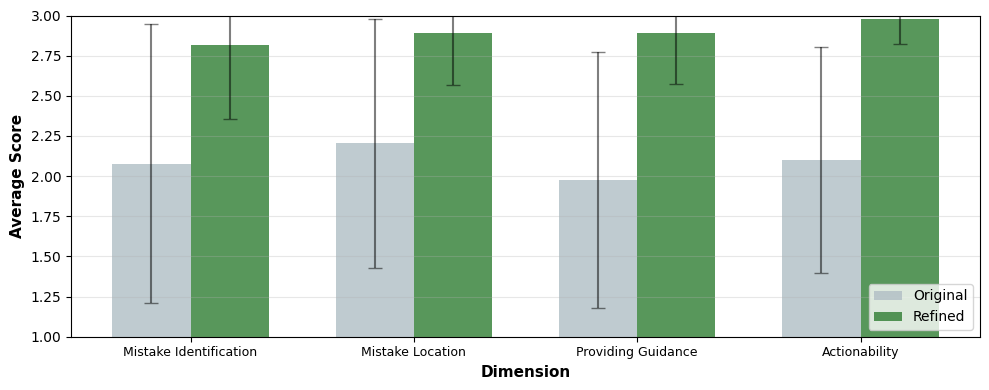

In [25]:
# Graph visualization of summary statistics from cell 24
import matplotlib.pyplot as plt
import numpy as np
from statistics import pstdev

# Recalculate statistics
criteria = [
    "mistake_identification",
    "mistake_location",
    "providing_guidance",
    "actionability",
]

original_overall = []
refined_overall = []
original_by_criterion = {c: [] for c in criteria}
refined_by_criterion = {c: [] for c in criteria}

for result in results:
    original_scores = result['llm_judge_scores'].get('original_scores', {})
    refined_scores = result['llm_judge_scores'].get('refined_scores', {})

    if original_scores:
        overall = original_scores.get('overall_score')
        if overall is not None:
            original_overall.append(overall)
        for c in criteria:
            score = original_scores.get(c, {}).get('score')
            if score is not None:
                original_by_criterion[c].append(score)

    if refined_scores:
        overall = refined_scores.get('overall_score')
        if overall is not None:
            refined_overall.append(overall)
        for c in criteria:
            score = refined_scores.get(c, {}).get('score')
            if score is not None:
                refined_by_criterion[c].append(score)

def safe_std(values):
    return pstdev(values) if len(values) > 1 else 0.0

labels = {
    "mistake_identification": "Mistake Identification",
    "mistake_location": "Mistake Location",
    "providing_guidance": "Providing Guidance",
    "actionability": "Actionability",
}

# Prepare data for plotting
criterion_labels = [labels[c] for c in criteria]
original_means = [np.mean(original_by_criterion[c]) if original_by_criterion[c] else 0 for c in criteria]
refined_means = [np.mean(refined_by_criterion[c]) if refined_by_criterion[c] else 0 for c in criteria]
original_stds = [safe_std(original_by_criterion[c]) if original_by_criterion[c] else 0 for c in criteria]
refined_stds = [safe_std(refined_by_criterion[c]) if refined_by_criterion[c] else 0 for c in criteria]

# Create figure with subplot
fig, ax1 = plt.subplots(figsize=(10, 4))

# Plot 1: Per-Criterion Comparison
x = np.arange(len(criteria))
width = 0.35

bars1 = ax1.bar(x - width/2, original_means, width, label='Original', color='#B0BEC5', alpha=0.8, capsize=5)
bars2 = ax1.bar(x + width/2, refined_means, width, label='Refined', color='#2E7D32', alpha=0.8, capsize=5)

# Add error bars
ax1.errorbar(x - width/2, original_means, yerr=original_stds, fmt='none', color='black', capsize=5, alpha=0.5)
ax1.errorbar(x + width/2, refined_means, yerr=refined_stds, fmt='none', color='black', capsize=5, alpha=0.5)

ax1.set_xlabel('Dimension', fontsize=11, fontweight='bold')
ax1.set_ylabel('Average Score', fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(criterion_labels, fontsize=9)
ax1.set_ylim([1, 3])
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

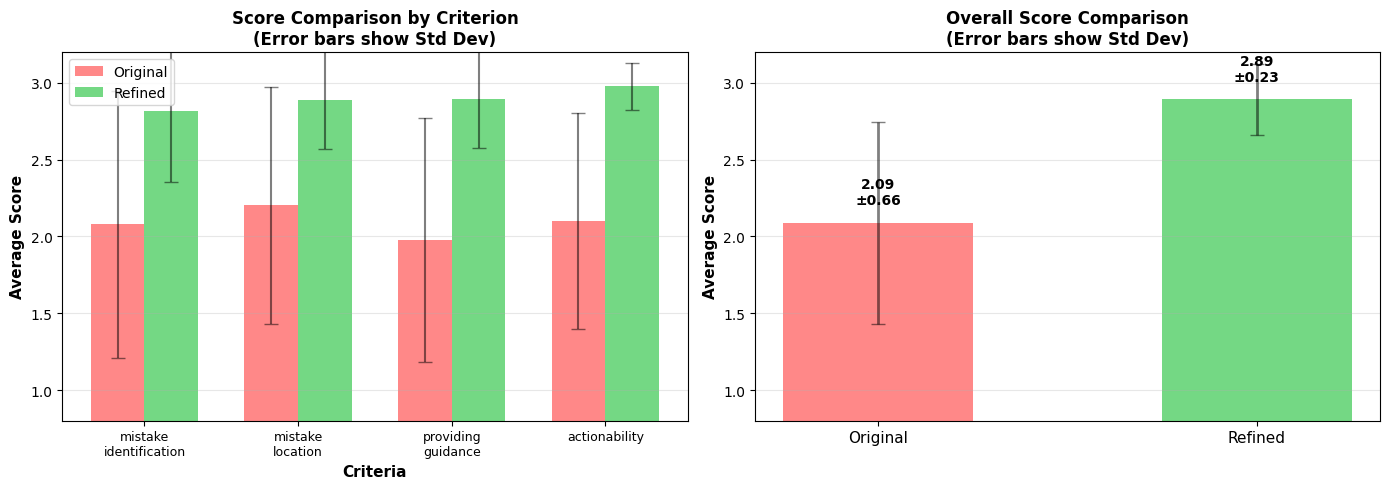

In [14]:
# Graph visualization of summary statistics from cell 24
import matplotlib.pyplot as plt
import numpy as np
from statistics import pstdev

# Recalculate statistics
criteria = [
    "mistake_identification",
    "mistake_location",
    "providing_guidance",
    "actionability",
]

original_overall = []
refined_overall = []
original_by_criterion = {c: [] for c in criteria}
refined_by_criterion = {c: [] for c in criteria}

for result in results:
    original_scores = result['llm_judge_scores'].get('original_scores', {})
    refined_scores = result['llm_judge_scores'].get('refined_scores', {})

    if original_scores:
        overall = original_scores.get('overall_score')
        if overall is not None:
            original_overall.append(overall)
        for c in criteria:
            score = original_scores.get(c, {}).get('score')
            if score is not None:
                original_by_criterion[c].append(score)

    if refined_scores:
        overall = refined_scores.get('overall_score')
        if overall is not None:
            refined_overall.append(overall)
        for c in criteria:
            score = refined_scores.get(c, {}).get('score')
            if score is not None:
                refined_by_criterion[c].append(score)

def safe_std(values):
    return pstdev(values) if len(values) > 1 else 0.0

# Prepare data for plotting
criterion_labels = [c.replace('_', '\n') for c in criteria]
original_means = [np.mean(original_by_criterion[c]) if original_by_criterion[c] else 0 for c in criteria]
refined_means = [np.mean(refined_by_criterion[c]) if refined_by_criterion[c] else 0 for c in criteria]
original_stds = [safe_std(original_by_criterion[c]) if original_by_criterion[c] else 0 for c in criteria]
refined_stds = [safe_std(refined_by_criterion[c]) if refined_by_criterion[c] else 0 for c in criteria]

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Per-Criterion Comparison
ax1 = axes[0]
x = np.arange(len(criteria))
width = 0.35

bars1 = ax1.bar(x - width/2, original_means, width, label='Original', color='#FF6B6B', alpha=0.8, capsize=5)
bars2 = ax1.bar(x + width/2, refined_means, width, label='Refined', color='#51CF66', alpha=0.8, capsize=5)

# Add error bars
ax1.errorbar(x - width/2, original_means, yerr=original_stds, fmt='none', color='black', capsize=5, alpha=0.5)
ax1.errorbar(x + width/2, refined_means, yerr=refined_stds, fmt='none', color='black', capsize=5, alpha=0.5)

ax1.set_xlabel('Criteria', fontsize=11, fontweight='bold')
ax1.set_ylabel('Average Score', fontsize=11, fontweight='bold')
ax1.set_title('Score Comparison by Criterion\n(Error bars show Std Dev)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(criterion_labels, fontsize=9)
ax1.set_ylim([0.8, 3.2])
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Overall Score Comparison
ax2 = axes[1]
overall_orig_mean = np.mean(original_overall) if original_overall else 0
overall_refined_mean = np.mean(refined_overall) if refined_overall else 0
overall_orig_std = safe_std(original_overall)
overall_refined_std = safe_std(refined_overall)

x_pos = [0, 1]
means = [overall_orig_mean, overall_refined_mean]
stds = [overall_orig_std, overall_refined_std]
colors = ['#FF6B6B', '#51CF66']
labels = ['Original', 'Refined']

bars = ax2.bar(x_pos, means, color=colors, alpha=0.8, capsize=5, width=0.5)
ax2.errorbar(x_pos, means, yerr=stds, fmt='none', color='black', capsize=5, alpha=0.5, linewidth=2)

# Add value labels on bars
for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{mean:.2f}\n±{std:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Average Score', fontsize=11, fontweight='bold')
ax2.set_title('Overall Score Comparison\n(Error bars show Std Dev)', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels, fontsize=11)
ax2.set_ylim([0.8, 3.2])
ax2.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()


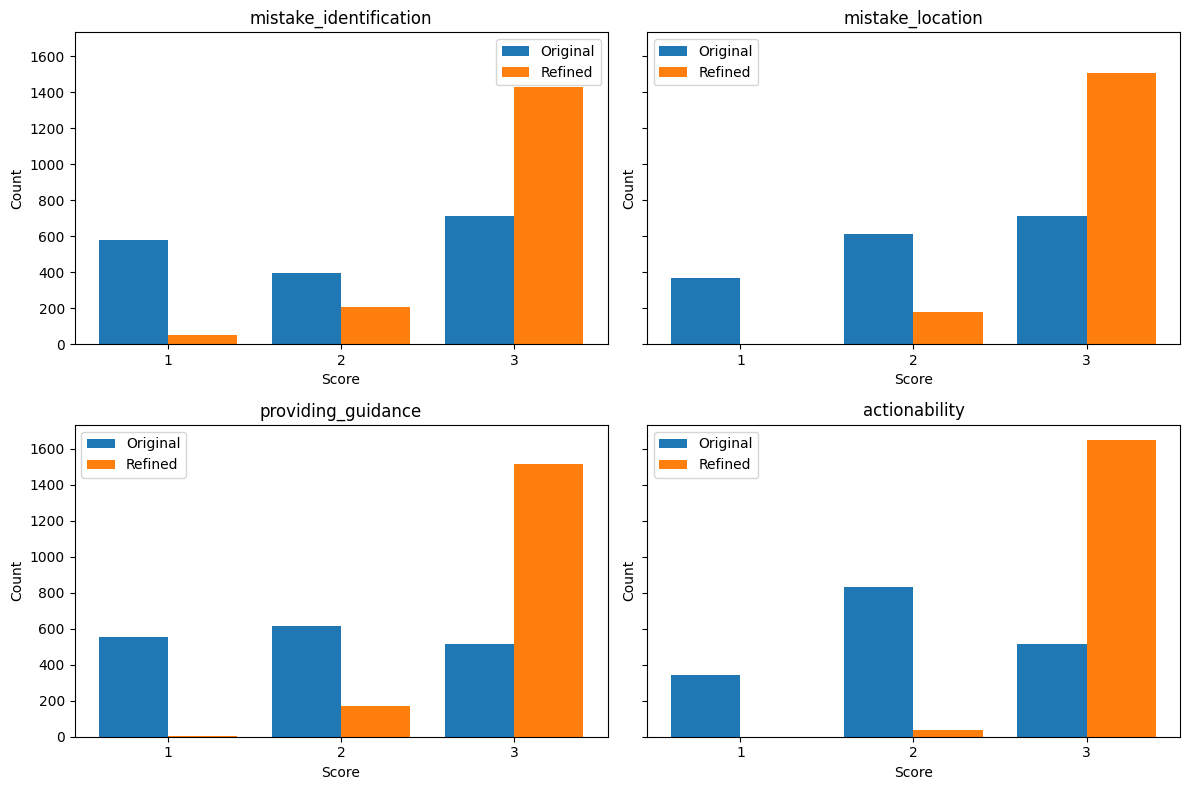

In [10]:
# Distribution plots for each criterion (Original vs Refined)
import matplotlib.pyplot as plt

criteria = [
    "mistake_identification",
    "mistake_location",
    "providing_guidance",
    "actionability",
]

score_levels = [1, 2, 3]

orig_counts = {c: {s: 0 for s in score_levels} for c in criteria}
ref_counts = {c: {s: 0 for s in score_levels} for c in criteria}

for result in results:
    original_scores = result.get("llm_judge_scores", {}).get("original_scores", {})
    refined_scores = result.get("llm_judge_scores", {}).get("refined_scores", {})

    for c in criteria:
        o_score = original_scores.get(c, {}).get("score")
        r_score = refined_scores.get(c, {}).get("score")

        if o_score in score_levels:
            orig_counts[c][o_score] += 1
        if r_score in score_levels:
            ref_counts[c][r_score] += 1

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

x = range(len(score_levels))
bar_width = 0.4

for ax, c in zip(axes, criteria):
    orig_vals = [orig_counts[c][s] for s in score_levels]
    ref_vals = [ref_counts[c][s] for s in score_levels]

    ax.bar([i - bar_width / 2 for i in x], orig_vals, width=bar_width, label="Original")
    ax.bar([i + bar_width / 2 for i in x], ref_vals, width=bar_width, label="Refined")

    ax.set_title(c)
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(s) for s in score_levels])
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

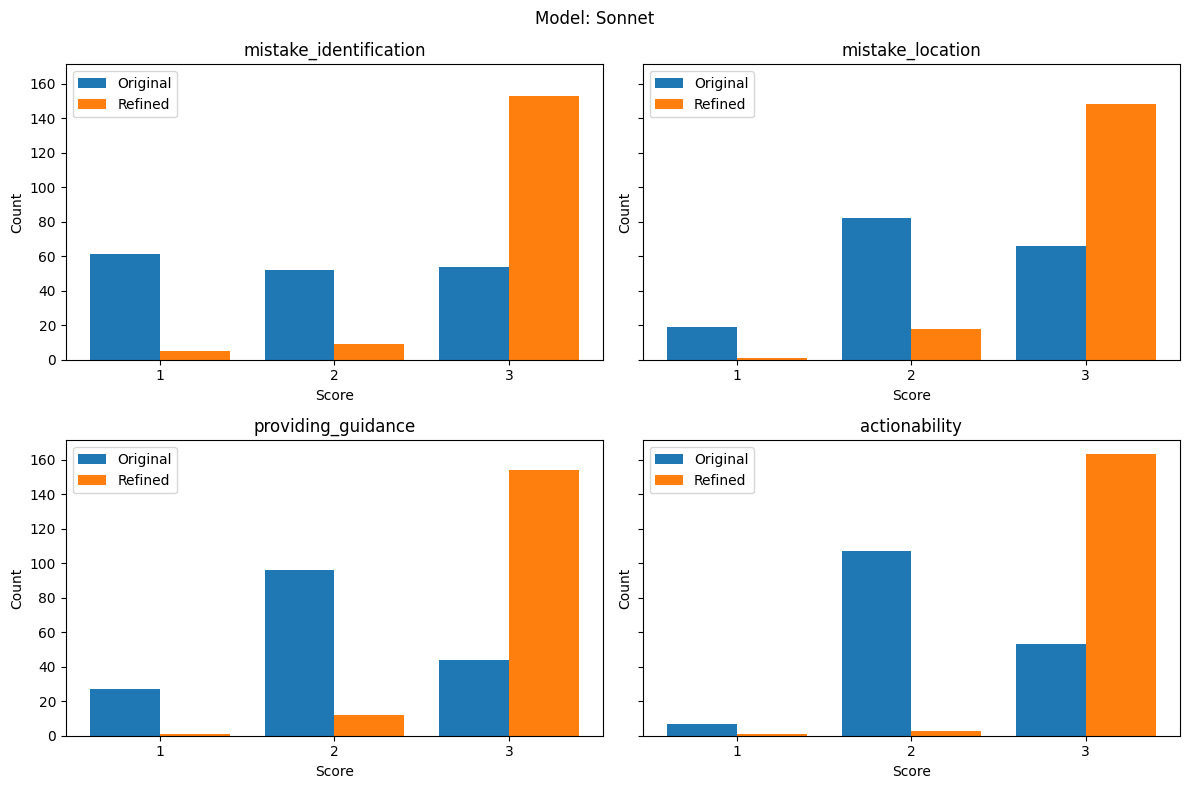

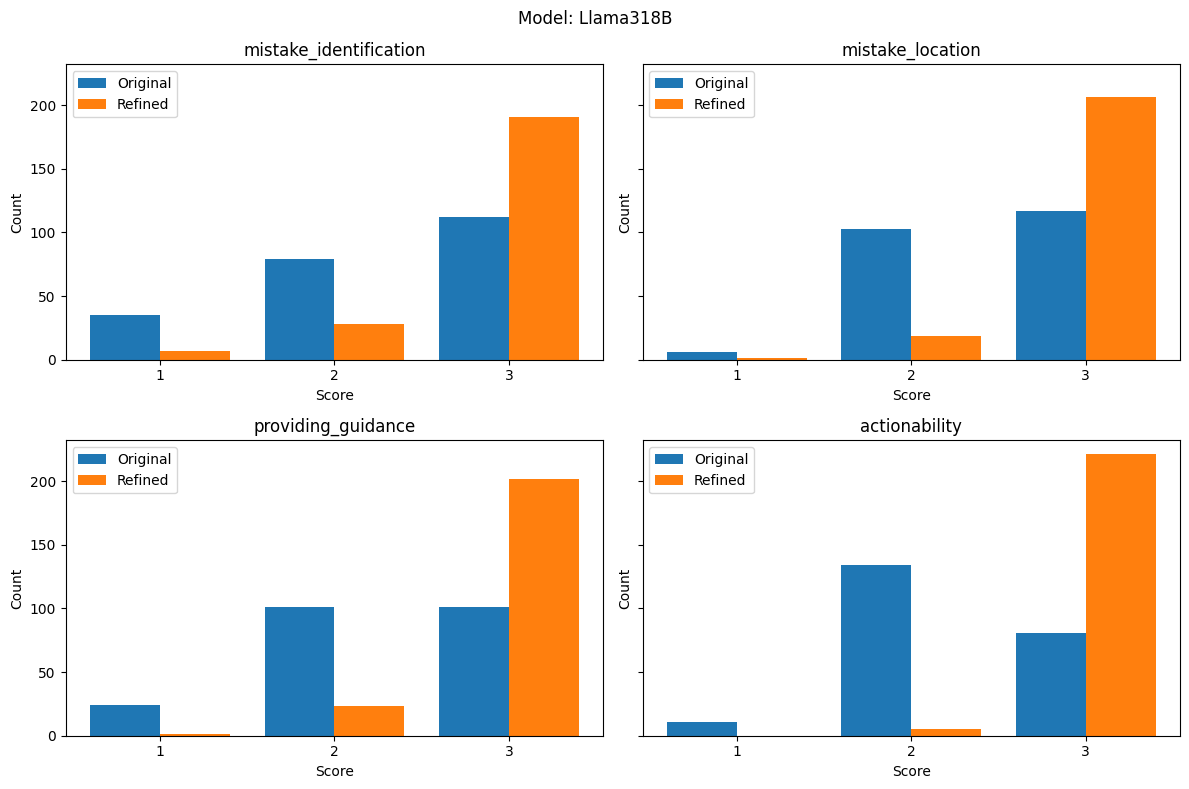

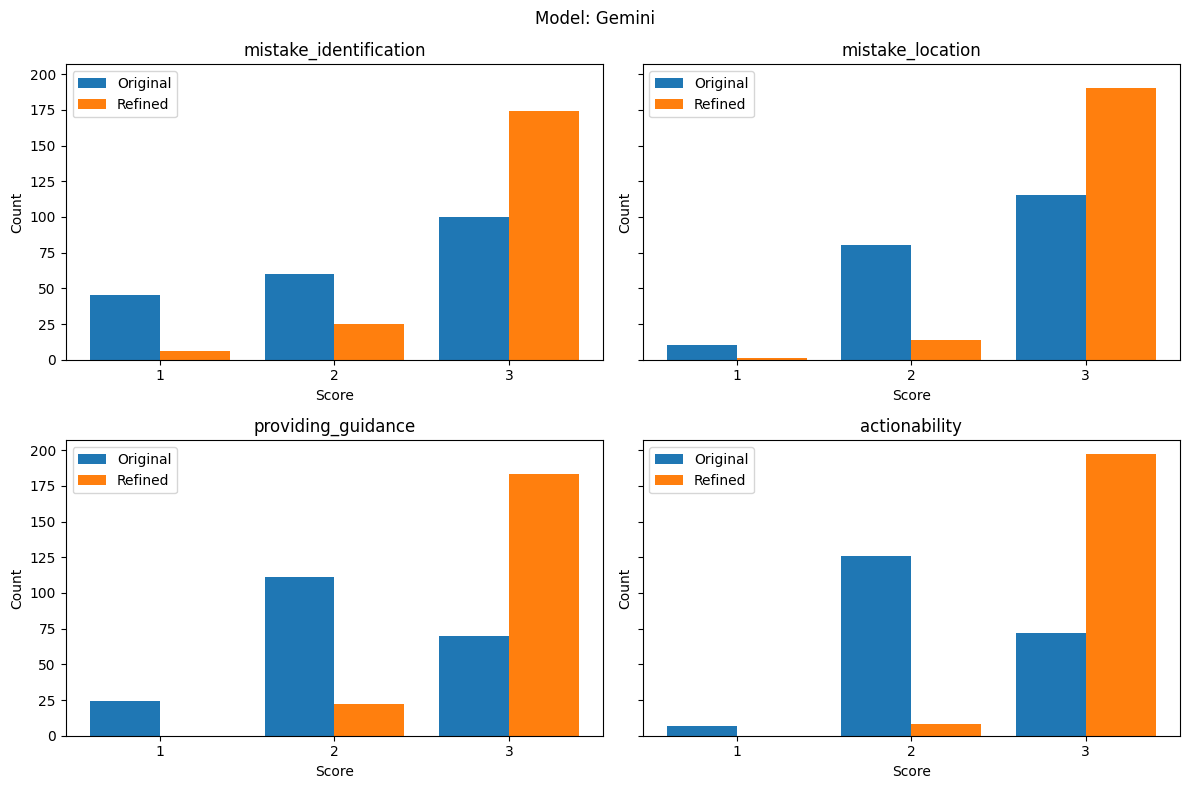

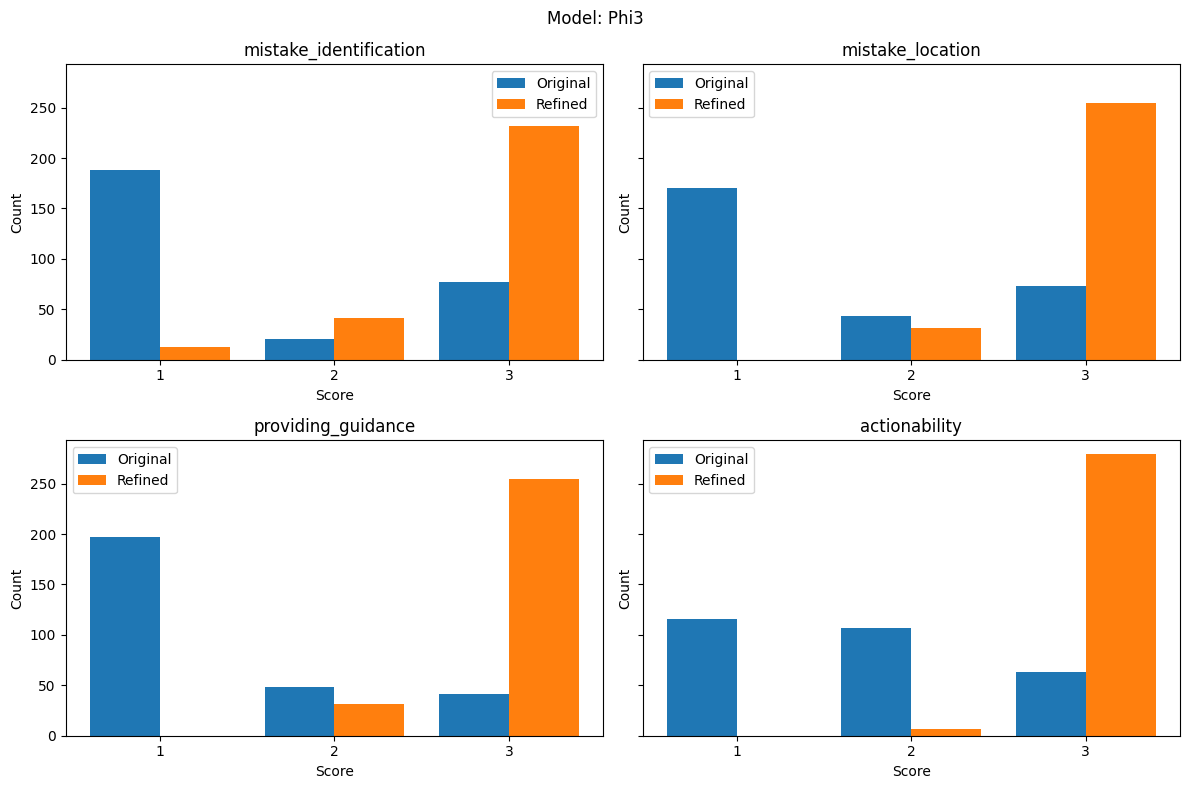

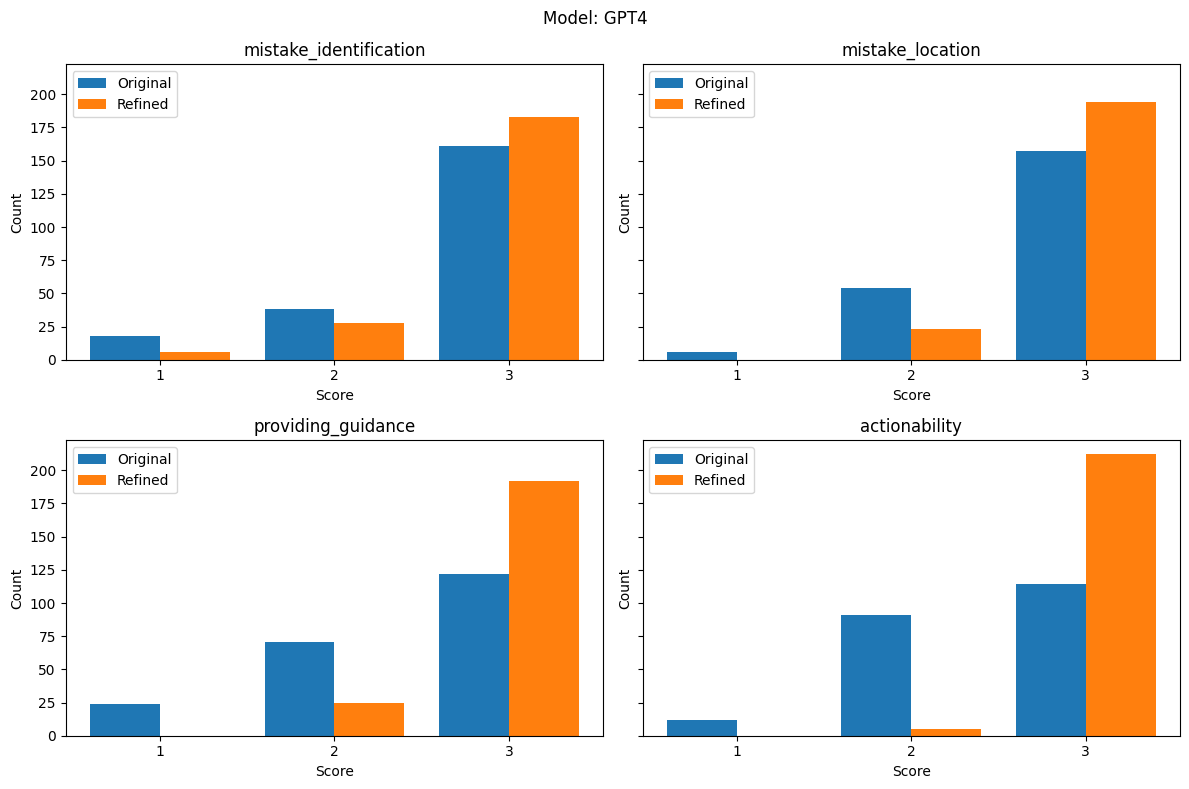

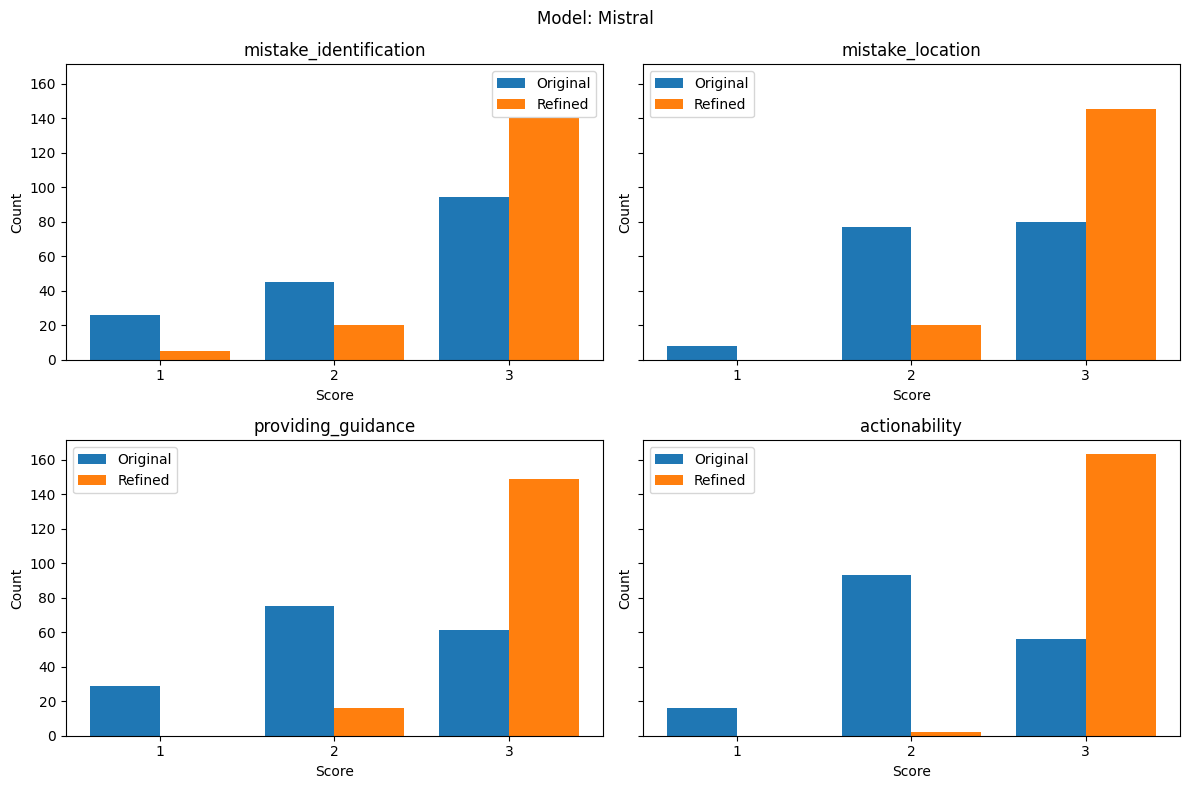

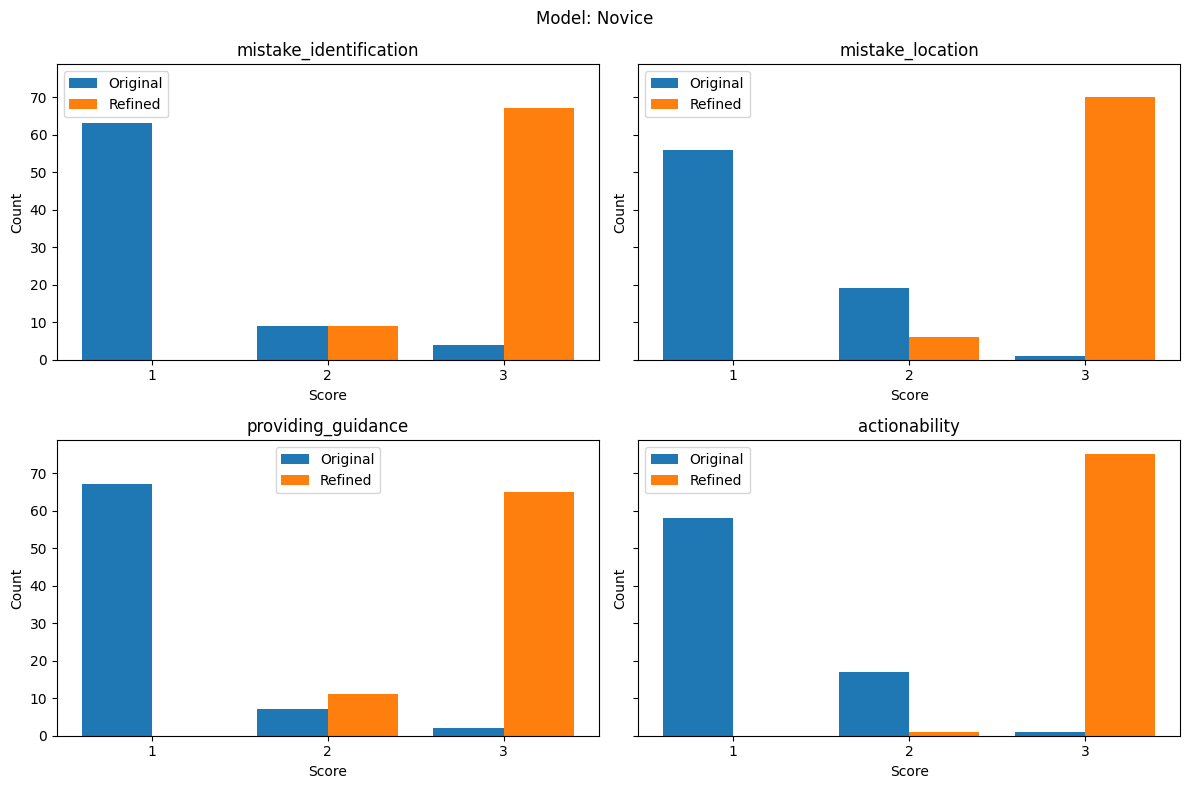

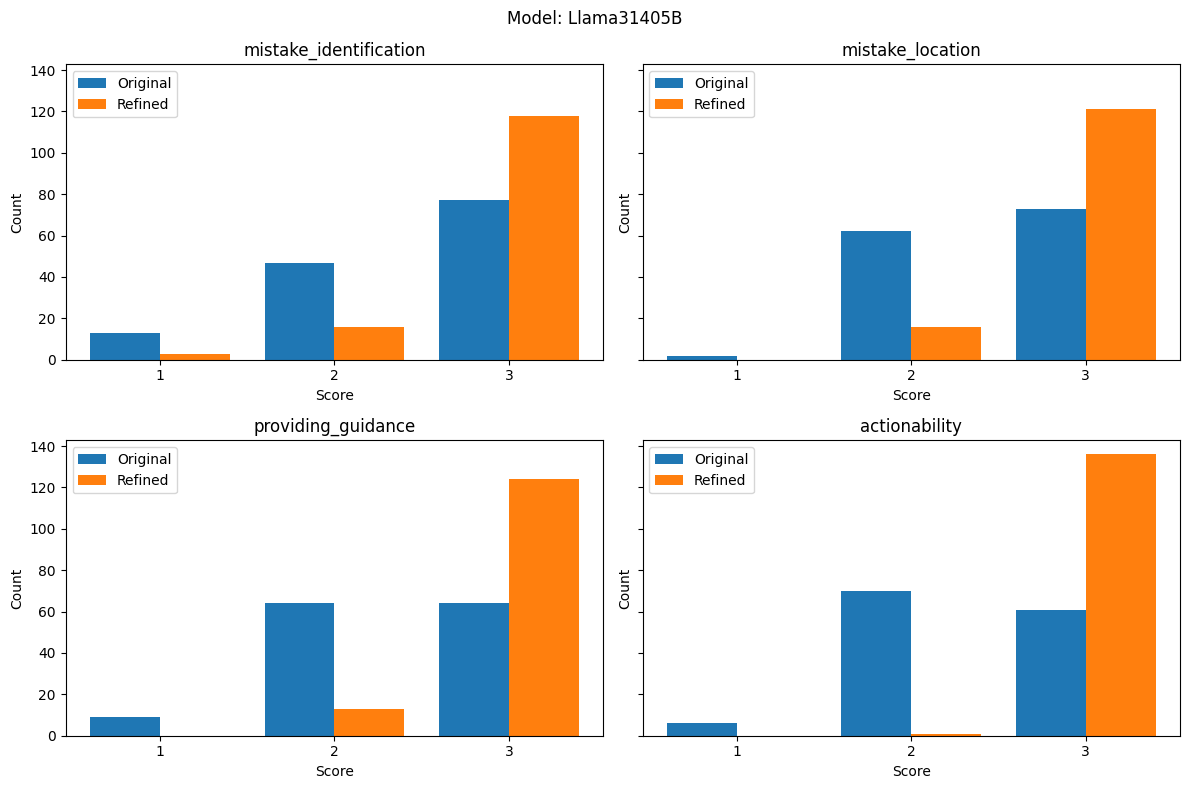

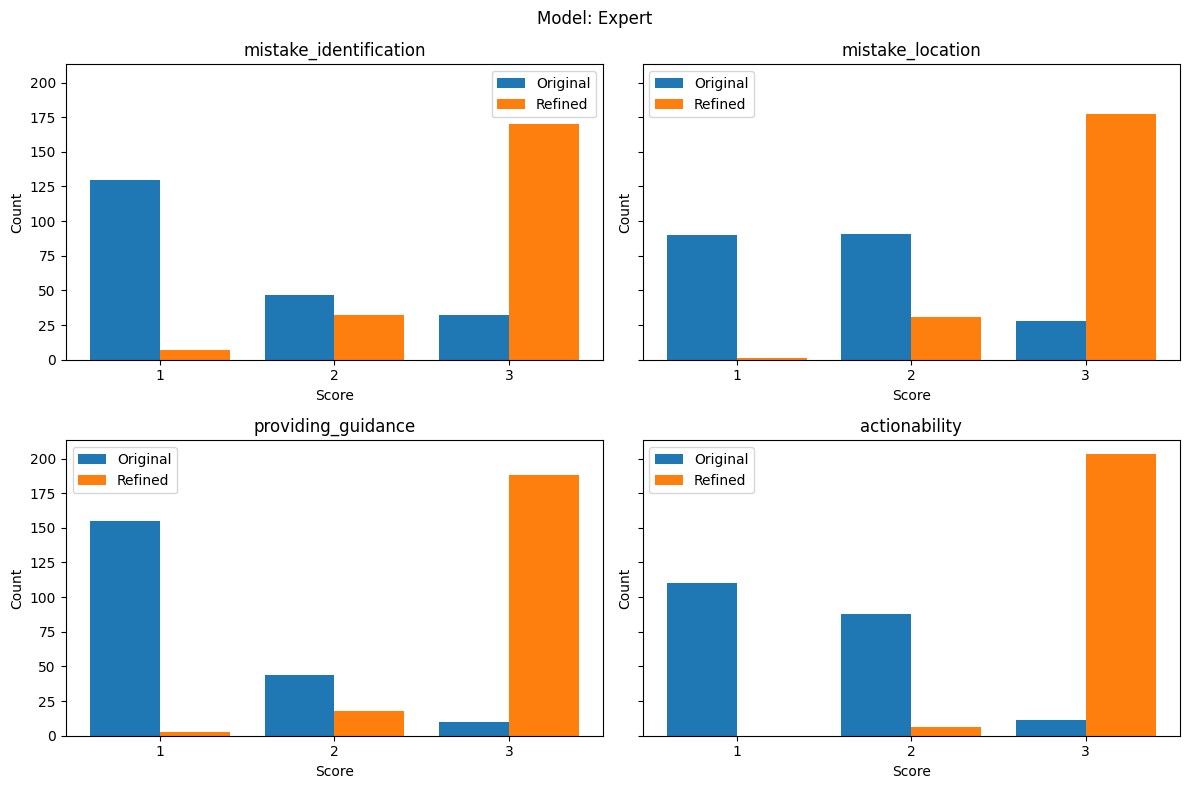

In [11]:
# Distribution plots by model (Original vs Refined)
import matplotlib.pyplot as plt

criteria = [
    "mistake_identification",
    "mistake_location",
    "providing_guidance",
    "actionability",
]

score_levels = [1, 2, 3]

# Group results by model_alias
models = {}
for result in results:
    model_alias = result.get("model_alias", "Unknown")
    models.setdefault(model_alias, []).append(result)

for model_alias, model_results in models.items():
    orig_counts = {c: {s: 0 for s in score_levels} for c in criteria}
    ref_counts = {c: {s: 0 for s in score_levels} for c in criteria}

    for result in model_results:
        original_scores = result.get("llm_judge_scores", {}).get("original_scores", {})
        refined_scores = result.get("llm_judge_scores", {}).get("refined_scores", {})

        for c in criteria:
            o_score = original_scores.get(c, {}).get("score")
            r_score = refined_scores.get(c, {}).get("score")

            if o_score in score_levels:
                orig_counts[c][o_score] += 1
            if r_score in score_levels:
                ref_counts[c][r_score] += 1

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
    axes = axes.flatten()

    x = range(len(score_levels))
    bar_width = 0.4

    for ax, c in zip(axes, criteria):
        orig_vals = [orig_counts[c][s] for s in score_levels]
        ref_vals = [ref_counts[c][s] for s in score_levels]

        ax.bar([i - bar_width / 2 for i in x], orig_vals, width=bar_width, label="Original")
        ax.bar([i + bar_width / 2 for i in x], ref_vals, width=bar_width, label="Refined")

        ax.set_title(c)
        ax.set_xticks(list(x))
        ax.set_xticklabels([str(s) for s in score_levels])
        ax.set_xlabel("Score")
        ax.set_ylabel("Count")
        ax.legend()

    fig.suptitle(f"Model: {model_alias}")
    plt.tight_layout()
    plt.show()

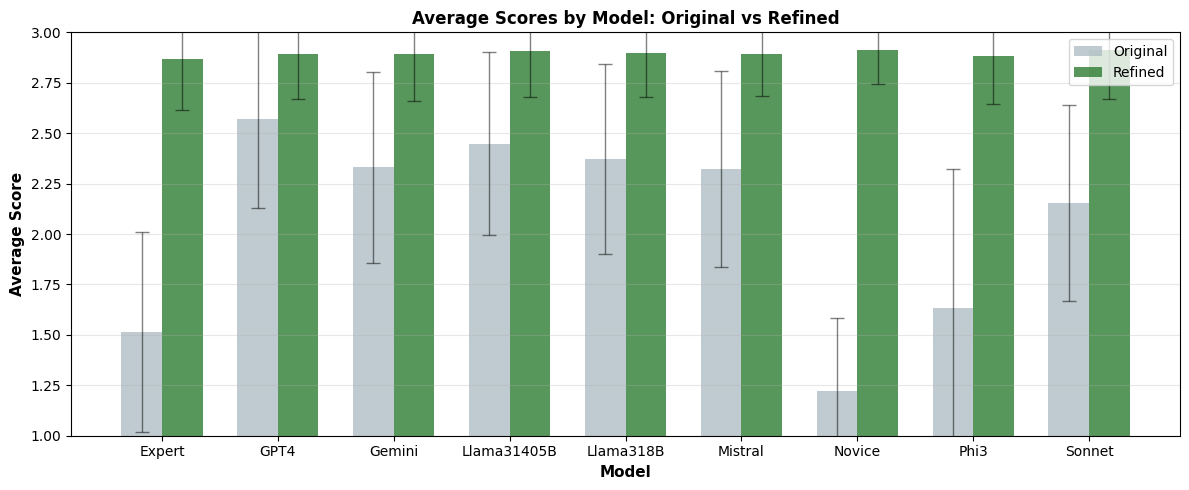

In [27]:
# Compare average scores across models (Original vs Refined)
import matplotlib.pyplot as plt
import numpy as np
from statistics import pstdev

criteria = [
    "mistake_identification",
    "mistake_location",
    "providing_guidance",
    "actionability",
]

# Group results by model
model_data = {}
for result in results:
    model_alias = result.get('model_alias', 'Unknown')
    if model_alias not in model_data:
        model_data[model_alias] = {'original': [], 'refined': []}
    
    # Get overall scores for this result
    original_overall = result['llm_judge_scores'].get('original_scores', {}).get('overall_score')
    refined_overall = result['llm_judge_scores'].get('refined_scores', {}).get('overall_score')
    
    if original_overall is not None:
        model_data[model_alias]['original'].append(original_overall)
    if refined_overall is not None:
        model_data[model_alias]['refined'].append(refined_overall)

def safe_std(values):
    return pstdev(values) if len(values) > 1 else 0.0

# Prepare data for plotting
models = sorted(model_data.keys())
original_means = [np.mean(model_data[m]['original']) if model_data[m]['original'] else 0 for m in models]
refined_means = [np.mean(model_data[m]['refined']) if model_data[m]['refined'] else 0 for m in models]
original_stds = [safe_std(model_data[m]['original']) if model_data[m]['original'] else 0 for m in models]
refined_stds = [safe_std(model_data[m]['refined']) if model_data[m]['refined'] else 0 for m in models]

# Create figure
fig, ax = plt.subplots(figsize=(12, 5))

# Calculate positions and width
x = np.arange(len(models))
width = 0.35

# Plot bars for original and refined
bars1 = ax.bar(x - width/2, original_means, width, label='Original', color='#B0BEC5', alpha=0.8, capsize=5)
bars2 = ax.bar(x + width/2, refined_means, width, label='Refined', color='#2E7D32', alpha=0.8, capsize=5)

# Add error bars
ax.errorbar(x - width/2, original_means, yerr=original_stds, fmt='none', color='black', 
            capsize=5, alpha=0.5, linewidth=1)
ax.errorbar(x + width/2, refined_means, yerr=refined_stds, fmt='none', color='black', 
            capsize=5, alpha=0.5, linewidth=1)

ax.set_xlabel('Model', fontsize=11, fontweight='bold')
ax.set_ylabel('Average Score', fontsize=11, fontweight='bold')
ax.set_title('Average Scores by Model: Original vs Refined', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim([1, 3])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()